In [ ]:
!pip install -r requirements.txt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

# Entangling atoms with the Rydberg gate
Goal: use the Rydberg gate to produce any one of the Bell states.

What if we apply it naively?

In [ ]:
# Enforce unitarity
zs = -0.988 - 0.155j
zs /= np.abs(zs)

# Unitary matrix
U = np.diag([1, -1, -1, zs])

CZ = UnitaryGate(U, label = 'CZ', num_qubits = 2)
CZ

**Note:** this is not the _canonical_ CZ gate, which, depending on the state of the control qubit applies a Z gate to the target qubit. The unitary of the canonical CZ gate is
$$
\mathrm{CZ}_\mathrm{can.} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1 \\
\end{pmatrix},
$$
whereas we have something closer to
$$ \mathrm{CZ}_\mathrm{Ryd.} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & -1 \\
\end{pmatrix}.
$$
One way to obtain the canonical gate is to apply an X operation to both qubits, thereby interchanging the roles of $0$ and $1$. (The resulting matrix still differs by an overall sign, but this is a global phase that can be multiplied out.)

In [ ]:
circ = QuantumCircuit(2)
circ.append(CZ, [0, 1])
circ.measure_all()
circ.draw(output = "latex")

In [ ]:
sampler = StatevectorSampler()
job = sampler.run([[circ, [[]], 100]])

In [ ]:
bs = job.result()[0].data.meas.get_bitstrings()
fig, ax = plt.subplots(figsize = (4, 3))
ax.hist(bs)
ax.set_xlabel('Bit string')
ax.set_ylabel('# measurements')

All qubits stay in the $|0\rangle$ state, not surprising, since our gate is purely a phase gate. So how can you use it to entangle the qubits?

## 1. Patching up the circuit
**Exercise**
- Write a circuit that uses the CZ gate defined above to entangle two atoms into a Bell pair. Hint: We’ve implemented a CZ gate, which applies a Z operation to the target if the control is 1. We can show that $HZH = X$, which you may find useful.
- Can you form any Bell pair using this gate? As a reminder, the four Bell states are:
  $$
    |\Psi^\pm\rangle = \frac{1}{\sqrt{2}}(|01\rangle \pm |10\rangle)
  $$
  $$
    |\Phi^\pm\rangle = \frac{1}{\sqrt{2}}(|00\rangle \pm |11\rangle).
  $$
- Is the CZ gate 'perfect'? If not, what's preventing it from being so?

In [ ]:
circ = QuantumCircuit(2)
circ.append(...)
...
circ.measure_all()

In [ ]:
sampler = StatevectorSampler()
job = sampler.run([[circ, [], 100]])

bs = job.result()[0].data.meas.get_bitstrings()
fig, ax = plt.subplots(figsize = (4, 3))
ax.hist(bs)
ax.set_xlabel('Bit string')
ax.set_ylabel('# measurements')
circ.draw(output = "latex")

## How good is this operation?

In [ ]:
state = Statevector(circ)
state

Using the state vector simulation can see that this is (close to) the state
$$
|\psi\rangle = \frac{1}{\sqrt{2}} \left(|01\rangle - |10\rangle \right),
$$
Let's calculate the overlap to see how good the fidelity actually is, we define it as
$$
\mathcal{F} = |\langle \psi_\mathrm{ideal} | \psi_\mathrm{actual} \rangle|^2.
$$

In [ ]:
ideal_state = Statevector([0, -1/np.sqrt(2), 1/np.sqrt(2), 0])
fidelity = np.abs(state.inner(ideal_state))**2
print(f"fidelity = {fidelity:.3f}")

We're roughly half a percent away from the ideal Bell state. What could be the reason for this?

## 2. How to determine entanglement?

**Exercise**

On a QPU we wouldn't be able to measure the state. How can we verify that we actually obtained the state we wanted?

- Measure the parity of the Bell state as a function of $\phi$ using the following circuit. Convince yourself that this turns the $|\Psi\rangle$ Bell state into the $|\Phi\rangle$ Bell state.

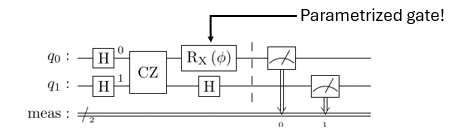

- Hint: Analyze the circuit output either by measuring the $ZZ$ operator using a `StatevectorEstimator`, or directly using the bitstrings that you get from the `StatevectorSampler()` used above.

In [ ]:
from qiskit.circuit import Parameter

In [ ]:
phi = Parameter("ϕ")
circ = QuantumCircuit(2)
...

circ.draw(output = "latex")

In [ ]:
sampler = StatevectorSampler()

phis = np.linspace(0, 2*np.pi, 50)
job = sampler.run([[circ, [phis], 4096]])

mr = job.result()[0].data.meas[0]